<a href="https://colab.research.google.com/github/Yahya1805/PCVK_GANJIL_2026/blob/main/WEEK6_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. PRAKTIKUM FILTER

Bagian ini berisi pengerjaan Jobsheet 6 - Praktikum Filter untuk mata kuliah Pengolahan Citra dan Visi Komputer.

## Identitas

Silakan isi NIM Anda pada cell di bawah ini sebelum menjalankan.

In [1]:
NAMA = 'M. Yahya Irvansyah'
NIM = '244107020032'

print(NAMA, NIM)

M. Yahya Irvansyah 244107020032


## Google Drive

Menghubungkan ke Google Drive untuk membaca dataset gambar praktikum.

In [2]:
from google.colab import drive
import os

# Mount drive
drive.mount('/content/drive')

folder = '/content/drive/MyDrive/PCVK/Pertemuan 6/'
if os.path.exists(folder):
    files = os.listdir(folder)
    print("File yang tersedia di folder:", files)
    # Pilih file gambar pertama yang valid jika ada
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    images = [f for f in files if f.lower().endswith(valid_extensions)]
    if images:
        PATH = os.path.join(folder, images[0])
        print(f"Selected PATH: {PATH}")
    else:
        PATH = None
        print("PERINGATAN: Tidak ada file gambar yang valid di folder tersebut.")
else:
    PATH = None
    print(f"PERINGATAN: Folder {folder} tidak ditemukan. Silakan buat folder tersebut di Drive Anda.")

Mounted at /content/drive
File yang tersedia di folder: ['djawatan.jpg', 'mandrill.tiff', 'lena.jpg']
Selected PATH: /content/drive/MyDrive/PCVK/Pertemuan 6/djawatan.jpg


## Import Library

Mengimpor library yang diperlukan untuk pengolahan citra dan visualisasi.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image

## Load Citra & Konversi Grayscale

Membaca citra masukan dan mengubahnya menjadi citra grayscale.

Ukuran citra asli: (720, 1080, 3)
Ukuran grayscale: (720, 1080)
dtype: uint8


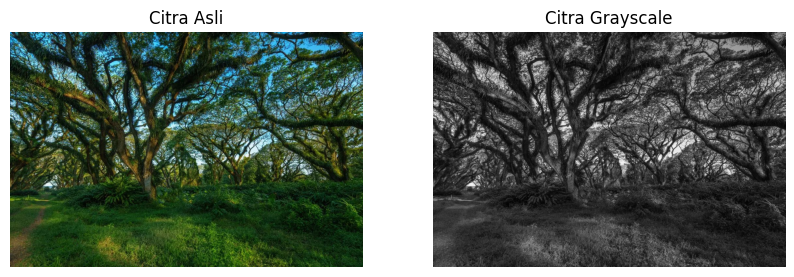

In [4]:
if PATH and os.path.exists(PATH):
    img = cv.imread(PATH)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Tampilkan informasi citra
    print("Ukuran citra asli:", img.shape)
    print("Ukuran grayscale:", gray.shape)
    print("dtype:", gray.dtype)

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[0].set_title("Citra Asli")
    axes[0].axis('off')

    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title("Citra Grayscale")
    axes[1].axis('off')
    plt.show()
else:
    print("Silakan masukkan gambar ke Drive Saya > PCVK > Pertemuan 6 terlebih dahulu, kemudian jalankan ulang cell di atas.")

## Fungsi Konvolusi Manual & Padding

Implementasi fungsi konvolusi 2D manual dengan dukungan padding otomatis sesuai dengan dimensi kernel ganjil.

In [5]:
def convolution2d(image, kernel, stride=1, padding=None):
    # Hitung padding otomatis jika tidak ditentukan
    kh, kw = kernel.shape
    if padding is None:
        pad_h = kh // 2
        pad_w = kw // 2
    else:
        pad_h = padding
        pad_w = padding

    # Melakukan padding pada citra
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    # Menghitung dimensi output
    ih, iw = image.shape
    oh = (ih + 2 * pad_h - kh) // stride + 1
    ow = (iw + 2 * pad_w - kw) // stride + 1

    output = np.zeros((oh, ow), dtype=np.float32)

    # Proses sliding window konvolusi
    for y in range(0, oh):
        for x in range(0, ow):
            window = padded_image[y*stride:y*stride+kh, x*stride:x*stride+kw]
            output[y, x] = np.sum(window * kernel)

    return output

## Pengujian Konvolusi dengan Sharpen

Melakukan pengujian fungsi konvolusi manual menggunakan kernel sharpening.

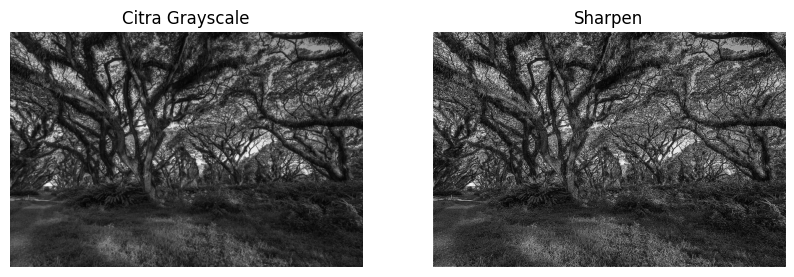

In [6]:
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

if 'gray' in globals():
    # Jalankan konvolusi
    sharpen_raw = convolution2d(gray, kernel_sharpen)
    sharpen = np.clip(sharpen_raw, 0, 255).astype(np.uint8)

    # Tampilkan hasil
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Citra Grayscale")
    axes[0].axis('off')

    axes[1].imshow(sharpen, cmap='gray')
    axes[1].set_title("Sharpen")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Pembuktian Fungsi Manual

Menampilkan dimensi dan rentang nilai dari output pengujian untuk memastikan hasil pengolahan citra valid.

In [7]:
if 'sharpen' in globals() and 'sharpen_raw' in globals():
    print("Shape input:", gray.shape)
    print("Shape kernel:", kernel_sharpen.shape)
    print("Shape output:", sharpen.shape)
    print("dtype output:", sharpen.dtype)
    print("Min output (setelah clipping):", sharpen.min())
    print("Max output (setelah clipping):", sharpen.max())
else:
    print("Lakukan pengujian sharpening terlebih dahulu.")

Shape input: (720, 1080)
Shape kernel: (3, 3)
Shape output: (720, 1080)
dtype output: uint8
Min output (setelah clipping): 0
Max output (setelah clipping): 255


## Average Filter

Filter perataan citra menggunakan kernel 3x3 seragam untuk memperhalus pixel.

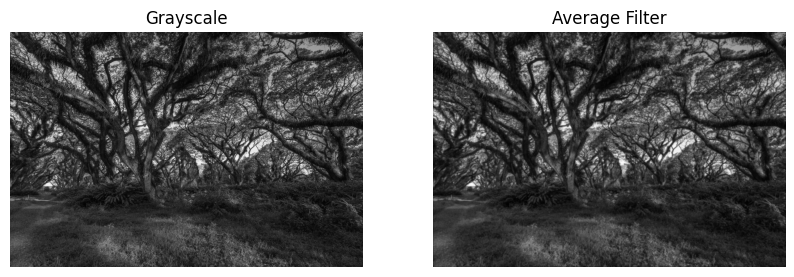

In [8]:
average_kernel = np.ones((3, 3), dtype=np.float32) / 9.0

if 'gray' in globals():
    average_out = np.clip(convolution2d(gray, average_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(average_out, cmap='gray')
    axes[1].set_title("Average Filter")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Low Pass Filter

Filter lolos rendah (Low Pass) untuk mereduksi komponen frekuensi tinggi / detail halus.

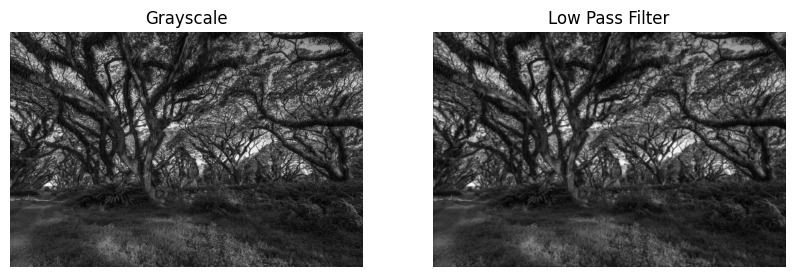

In [9]:
low_pass_kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float32) / 9.0

if 'gray' in globals():
    low_pass_out = np.clip(convolution2d(gray, low_pass_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(low_pass_out, cmap='gray')
    axes[1].set_title("Low Pass Filter")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## High Pass Filter

Filter lolos tinggi (High Pass) menonjolkan batas/tepi citra dengan memotong intensitas frekuensi rendah.

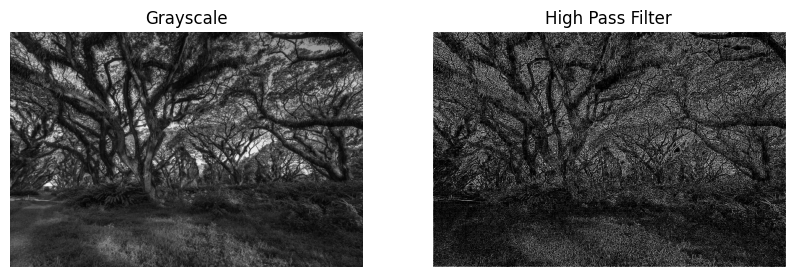

In [10]:
high_pass_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

if 'gray' in globals():
    high_pass_out = np.clip(convolution2d(gray, high_pass_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(high_pass_out, cmap='gray')
    axes[1].set_title("High Pass Filter")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Sharpen Filter

Filter penajaman tepi citra menggunakan kernel penajaman standar.

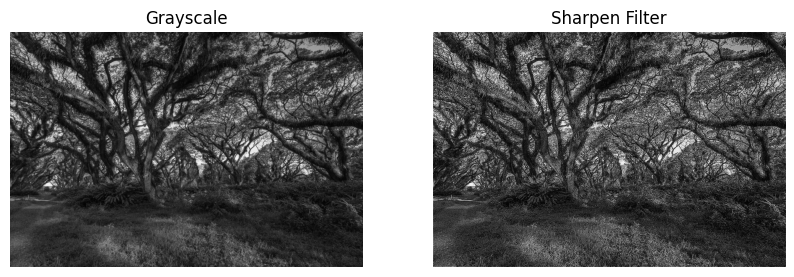

In [11]:
kernel_sharpen_2 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

if 'gray' in globals():
    sharpen_out = np.clip(convolution2d(gray, kernel_sharpen_2), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(sharpen_out, cmap='gray')
    axes[1].set_title("Sharpen Filter")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Emboss Filter

Filter emboss memberikan efek timbul 3D berdasarkan gradien intensitas diagonal.

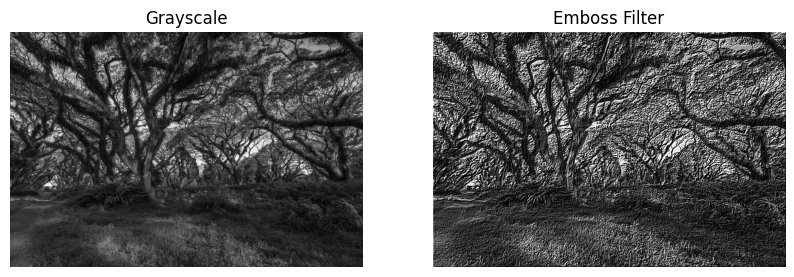

In [12]:
emboss_kernel = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
], dtype=np.float32)

if 'gray' in globals():
    emboss_out = np.clip(convolution2d(gray, emboss_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(emboss_out, cmap='gray')
    axes[1].set_title("Emboss Filter")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Left Sobel Edge Detection

Kernel deteksi tepi Left Sobel mendeteksi perubahan kontras intensitas arah horizontal.

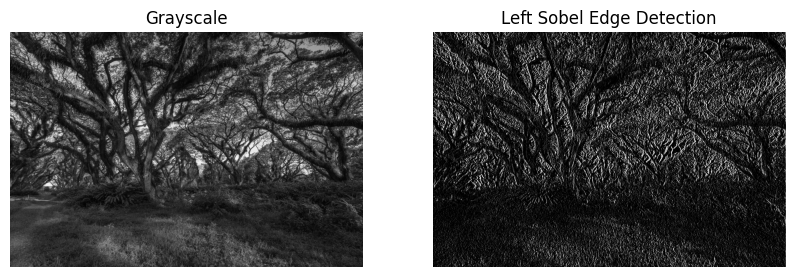

In [13]:
left_sobel_kernel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

if 'gray' in globals():
    left_sobel_out = np.clip(convolution2d(gray, left_sobel_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(left_sobel_out, cmap='gray')
    axes[1].set_title("Left Sobel Edge Detection")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Canny Edge Detection Kernel

Penerapan kernel konvolusi Canny yang diberikan pada jobsheet praktikum.

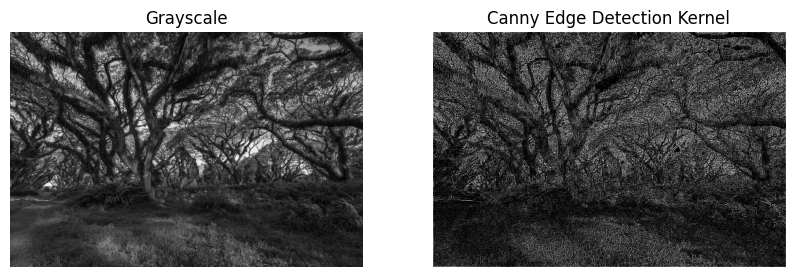

In [14]:
canny_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

if 'gray' in globals():
    canny_out = np.clip(convolution2d(gray, canny_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(canny_out, cmap='gray')
    axes[1].set_title("Canny Edge Detection Kernel")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## 21x21 Gaussian Blur

Pembuatan filter Gaussian 21x21 menggunakan kernel generator 1D dari OpenCV, diaplikasikan menggunakan konvolusi manual.

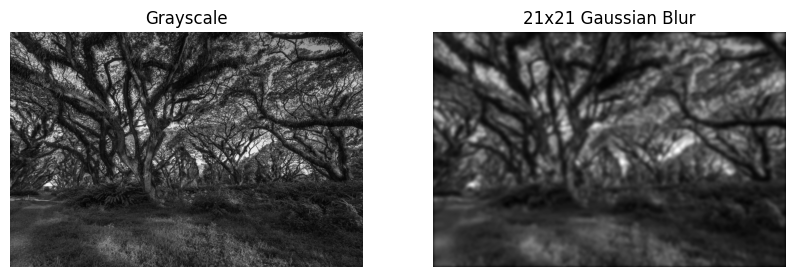

In [15]:
kernel_size = 21
sigma = math.sqrt(kernel_size)

gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gaussian_1d @ gaussian_1d.transpose()

if 'gray' in globals():
    gaussian_out = np.clip(convolution2d(gray, gaussian_kernel), 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title("Grayscale")
    axes[0].axis('off')
    axes[1].imshow(gaussian_out, cmap='gray')
    axes[1].set_title("21x21 Gaussian Blur")
    axes[1].axis('off')
    plt.show()
else:
    print("Citra grayscale belum di-load.")

## Perbandingan Semua Filter

Menampilkan seluruh citra hasil pemrosesan filter dalam satu kesatuan layout visual.

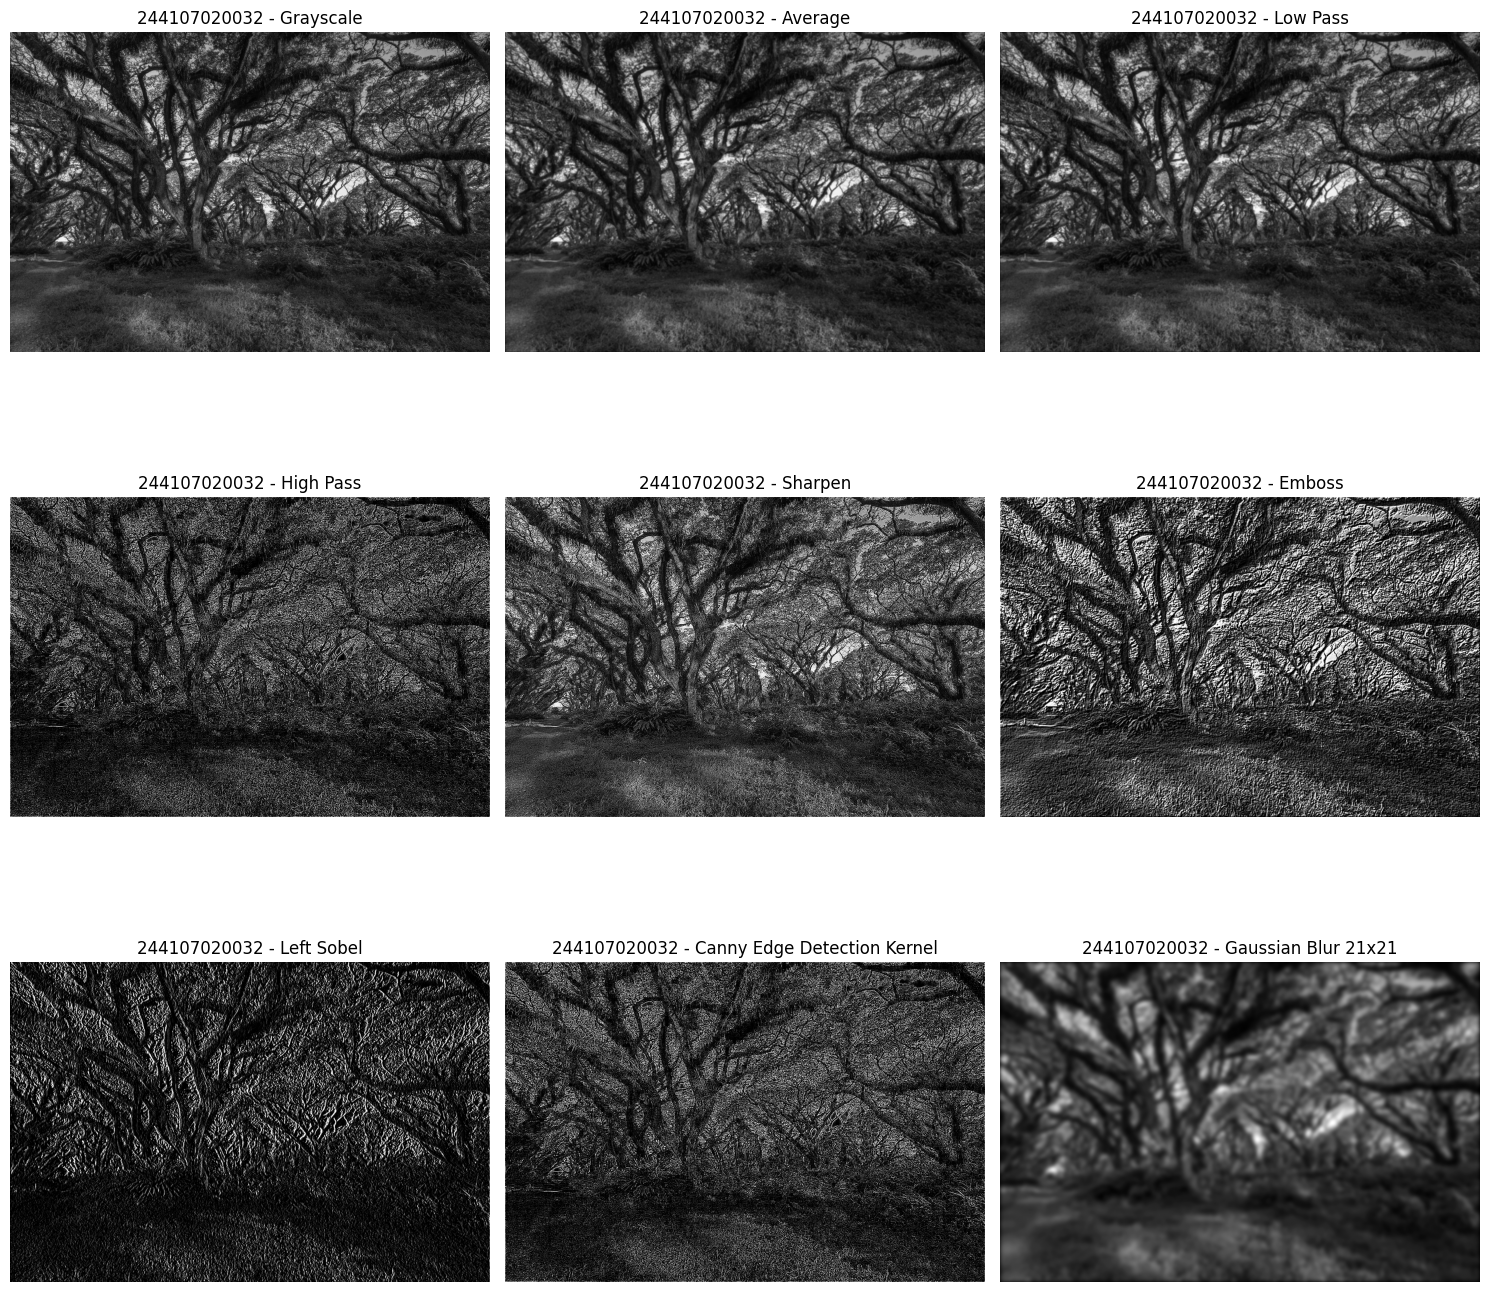

In [16]:
if 'gray' in globals():
    # Menentukan judul dinamis berdasarkan NIM
    prefix = f"{NIM} - "

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    # Map subplot ke hasil filter
    filters_data = [
        (gray, "Grayscale"),
        (average_out, "Average"),
        (low_pass_out, "Low Pass"),
        (high_pass_out, "High Pass"),
        (sharpen_out, "Sharpen"),
        (emboss_out, "Emboss"),
        (left_sobel_out, "Left Sobel"),
        (canny_out, "Canny Edge Detection Kernel"),
        (gaussian_out, "Gaussian Blur 21x21")
    ]

    for i, (img_res, title_name) in enumerate(filters_data):
        ax = axes[i // 3, i % 3]
        ax.imshow(img_res, cmap='gray')
        ax.set_title(prefix + title_name)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Silakan jalankan semua filter di atas terlebih dahulu.")

## Kesimpulan

Dari praktikum filter ini, diperoleh beberapa kesimpulan:
1. Konvolusi manual 2D berhasil diimplementasikan dengan operasi pergeseran kernel (sliding window) dan padding otomatis.
2. Filter low-pass dan average filter efektif dalam menghaluskan gambar dan menyamarkan noise halus.
3. Filter high-pass, sharpening, sobel, dan canny kernel efektif menonjolkan area tepi atau gradien perubahan intensitas pixel secara signifikan.